In [4]:
import numpy as np
import os # Importing the os module
from sklearn.metrics import confusion_matrix
import seaborn as sn; sn.set(font_scale=1.4)
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tqdm import tqdm

In [5]:
class_names=['cats','dogs']
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

nb_classes = len(class_names)

IMAGE_SIZE = (150, 150)

In [6]:
def load_data():
  # Updated paths to use raw strings and forward slashes for better cross-platform compatibility
  datasets=["/content/drive/MyDrive/archive/dataset/training_set","/content/drive/MyDrive/archive/dataset/test_set"]
  output=[]
  for dataset in datasets:
    images=[]
    labels=[]
    print("Loading {}".format(dataset))

    # Corrected indentation for the following loop:
    for folder in os.listdir(dataset):
      label = class_names_label[folder] # Corrected variable name to 'label'
      for file in tqdm(os.listdir(os.path.join(dataset, folder))):

        img_path = os.path.join(os.path.join(dataset, folder), file)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #if you need change color to black and white
        image = cv2.resize(image, IMAGE_SIZE)
        images.append(image)
        labels.append(label) # Corrected variable name to 'label'

    images = np.array(images, dtype="float32")
    labels = np.array(labels, dtype="int32")
    output.append((images, labels))

  return output

In [7]:
(train_images, train_labels), (test_images, test_labels) = load_data()

Loading /content/drive/MyDrive/archive/dataset/training_set


100%|██████████| 4000/4000 [01:28<00:00, 45.30it/s] 


Loading /content/drive/MyDrive/archive/dataset/test_set


100%|██████████| 1000/1000 [00:20<00:00, 49.75it/s]


In [8]:
train_images, train_labels = shuffle(train_images, train_labels, random_state=25)

In [9]:
n_train = train_labels.shape[0]
n_test = test_labels.shape[0]
print("Number of training examples: {}".format(n_train))
print("Number of testing examples: {}".format(n_test))

Number of training examples: 8000
Number of testing examples: 2002


In [10]:
train_images=train_images/255.0
test_images=test_images/255.0

In [11]:
def display_random_images(class_names, images, labels):
  index=np.random.randint(images.shape[0])
  plt.figure()
  plt.imshow(images[index])
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.title('Image #{}:'.format(index) + ' {}'.format(class_names[labels[index]]))
  plt.show()




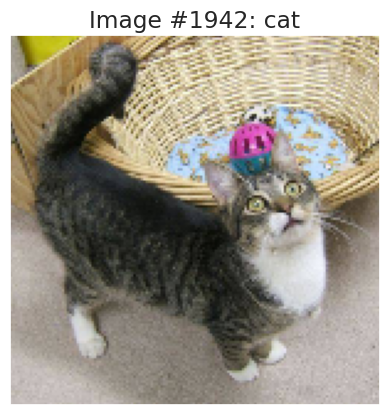

In [41]:
display_random_images(class_names, train_images, train_labels)

In [16]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation=tf.nn.relu),
    tf.keras.layers.Dense(2, activation=tf.nn.softmax)
])

In [17]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [18]:
history=model.fit(train_images,train_labels,batch_size=200,epochs=20,validation_data=(test_images,test_labels))

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 225ms/step - accuracy: 0.5063 - loss: 0.7785 - val_accuracy: 0.5559 - val_loss: 0.6821
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - accuracy: 0.5900 - loss: 0.6679 - val_accuracy: 0.6234 - val_loss: 0.6428
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - accuracy: 0.6411 - loss: 0.6323 - val_accuracy: 0.6808 - val_loss: 0.5894
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - accuracy: 0.6954 - loss: 0.5730 - val_accuracy: 0.6938 - val_loss: 0.5800
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.7234 - loss: 0.5410 - val_accuracy: 0.7438 - val_loss: 0.5307
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.7621 - loss: 0.4917 - val_accuracy: 0.7817 - val_loss: 0.4843
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - accuracy: 0.7893 - loss: 0.4457 - val_accuracy: 0.7747 - val_loss: 0.4674
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.8129 - loss: 0.4029 - val_accuracy

In [19]:
test_images

array([[[[0.9607843 , 0.96862745, 0.9647059 ],
         [0.9098039 , 0.92156863, 0.9137255 ],
         [0.85882354, 0.8627451 , 0.85882354],
         ...,
         [0.9607843 , 0.972549  , 0.99215686],
         [0.96862745, 0.98039216, 0.99607843],
         [0.9647059 , 0.9764706 , 0.99215686]],

        [[0.972549  , 0.98039216, 0.98039216],
         [0.8745098 , 0.88235295, 0.8784314 ],
         [0.85882354, 0.8666667 , 0.8627451 ],
         ...,
         [0.94509804, 0.95686275, 0.9764706 ],
         [0.9411765 , 0.9529412 , 0.972549  ],
         [0.9254902 , 0.9372549 , 0.95686275]],

        [[0.972549  , 0.9764706 , 0.9764706 ],
         [0.8784314 , 0.8862745 , 0.88235295],
         [0.85490197, 0.8627451 , 0.85882354],
         ...,
         [0.9137255 , 0.9254902 , 0.94509804],
         [0.92941177, 0.9411765 , 0.9607843 ],
         [0.93333334, 0.94509804, 0.9647059 ]],

        ...,

        [[0.95686275, 0.9372549 , 0.7764706 ],
         [1.        , 0.9843137 , 0.81960785]

In [21]:
y_pred=model.predict(test_images)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


In [23]:
y_pred[-1]

array([0.04611627, 0.9538837 ], dtype=float32)

In [37]:
from tensorflow.keras.preprocessing import image
img=image.load_img('/content/drive/MyDrive/archive/dataset/single_prediction/cat_or_dog_1.jpg',target_size=(150,150))


In [38]:
img_array=image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)
img_array=img_array/255.0


In [39]:

prediction=model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [40]:
class_names=['cat','dog']
predict_class=class_names[np.argmax(prediction)]
predict_class

'dog'